# Tech Challenge Postech — Fase 2
## Previsão de Alta/Baixa do IBOVESPA — Random Forest

**Baseline final:** 52 features | **Dados fixados:** 01/01/2015 → 03/03/2026
**Pipeline 100% livre de data leakage**


## Imports


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

## 1. Coleta de Dados

Dados fixados em **03/03/2026**: IBOVESPA



In [2]:
print("Baixando dados...")

df = yf.download("^BVSP", start="2015-01-01", end="2026-03-03",
                 interval="1d", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
df.index = pd.to_datetime(df.index)
df = df[df.index <= '2026-03-02']

sp500  = yf.download("^GSPC", start="2015-01-01", end="2026-03-03",
                     auto_adjust=True)['Close']
usdbrl = yf.download("BRL=X", start="2015-01-01", end="2026-03-03",
                     auto_adjust=True)['Close']
vix    = yf.download("^VIX",  start="2015-01-01", end="2026-03-03",
                     auto_adjust=True)['Close']

for s in [sp500, usdbrl, vix]:
    s.index = pd.to_datetime(s.index)

sp500  = sp500[sp500.index   <= '2026-03-02']
usdbrl = usdbrl[usdbrl.index <= '2026-03-02']
vix    = vix[vix.index       <= '2026-03-02']

close  = df['Close']
high   = df['High']
low    = df['Low']
volume = df['Volume']

print(f"IBOVESPA: {df.index[0].date()} → {df.index[-1].date()} | {len(df)} pregões")

Baixando dados...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

IBOVESPA: 2015-01-02 → 2026-03-02 | 2769 pregões


---
## Análise Exploratória dos Dados (EDA)

Antes de qualquer modelagem, exploramos a qualidade e a estrutura da base, identificamos padrões e validamos que os dados estão prontos para uso.


### 1.1 Visão Geral da Base Bruta


In [3]:
print("="*60)
print(f"Shape do DataFrame IBOVESPA : {df.shape}")
print(f"Período                      : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Pregões disponíveis          : {len(df)}")
print("="*60)

# Primeiras e últimas linhas
print("\n🔎 Primeiras 5 linhas:")
display(df.head())

print("\n🔎 Últimas 5 linhas:")
display(df.tail())

# Estatísticas descritivas
print("\n📊 Estatísticas descritivas:")
display(df.describe().round(2))

# Valores ausentes
print("\n⚠️  Valores ausentes por coluna:")
missing = df.isnull().sum()
display(missing[missing >= 0].rename("NaN count").to_frame())

Shape do DataFrame IBOVESPA : (2769, 5)
Período                      : 2015-01-02 → 2026-03-02
Pregões disponíveis          : 2769

🔎 Primeiras 5 linhas:


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,50005.0,50005.0,48345.0,48512.0,2882100
2015-01-05,48512.0,48512.0,47264.0,47517.0,3866100
2015-01-06,47517.0,48061.0,47338.0,48001.0,4559300
2015-01-07,48006.0,49882.0,48006.0,49463.0,4408800
2015-01-08,49463.0,50261.0,49017.0,49943.0,3621900



🔎 Últimas 5 linhas:


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-02-24,188855.0,191781.0,188855.0,191490.0,11037300
2026-02-25,191491.0,192624.0,190419.0,191248.0,9134900
2026-02-26,191248.0,191978.0,188977.0,191005.0,8797400
2026-02-27,191005.0,191005.0,188478.0,188787.0,11002300
2026-03-02,188786.0,190110.0,186638.0,189307.0,9090200



📊 Estatísticas descritivas:


Price,Open,High,Low,Close,Volume
count,2769.00,2769.00,2769.00,2769.00,2769.00
mean,97522.96,98377.31,96717.82,97571.63,7490597.44
std,30553.51,30696.69,30445.16,30589.16,4148239.90
min,37501.00,38031.00,37046.00,37497.00,0.00
25%,72428.00,73139.00,71356.00,72429.00,3753500.00
50%,103165.00,104172.00,102233.00,103220.00,7237000.00
75%,119394.00,120222.00,118693.00,119429.00,10540900.00
max,191491.00,192624.00,190419.00,191490.00,26029300.00



⚠️  Valores ausentes por coluna:


,NaN count
Price,
Open,0
High,0
Low,0
Close,0
Volume,0


### 1.2 Série Histórica do IBOVESPA com Volume


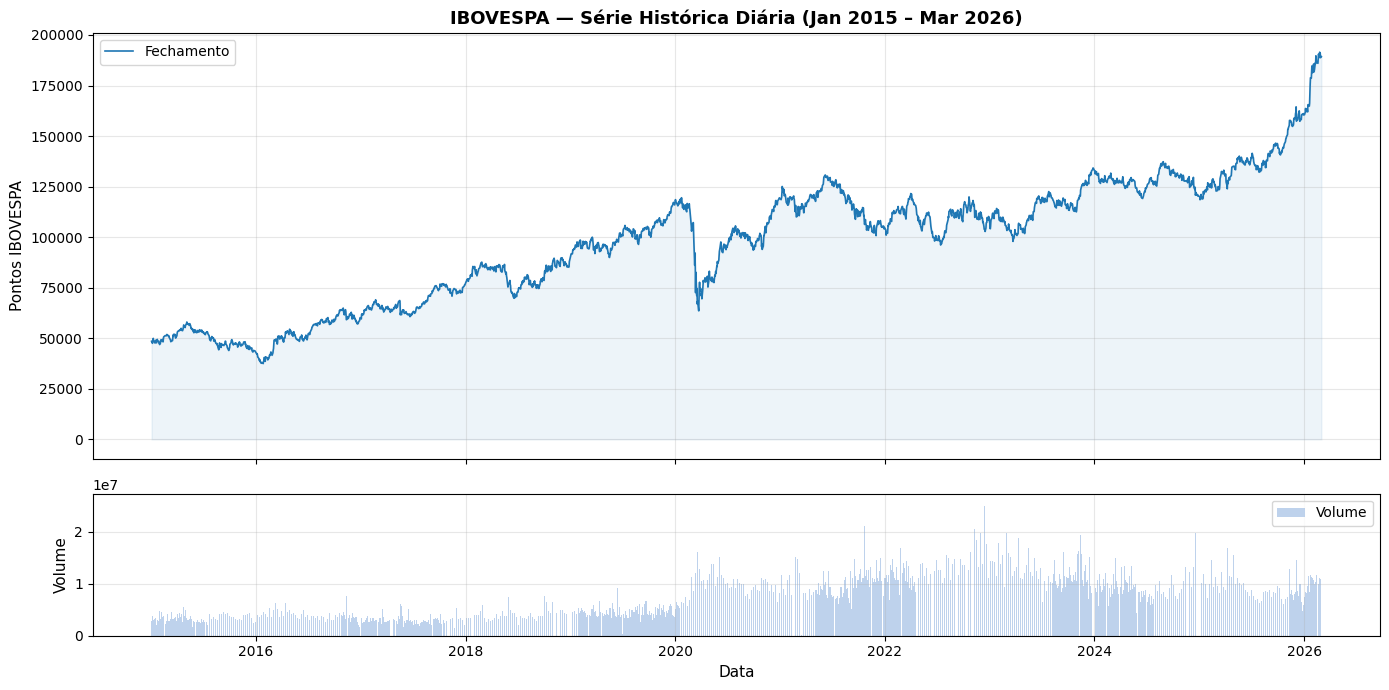

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7),
                                gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Preço de fechamento
ax1.plot(df.index, df['Close'], color='#1f77b4', linewidth=1.2, label='Fechamento')
ax1.fill_between(df.index, df['Close'], alpha=0.08, color='#1f77b4')
ax1.set_ylabel('Pontos IBOVESPA', fontsize=11)
ax1.set_title('IBOVESPA — Série Histórica Diária (Jan 2015 – Mar 2026)',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Volume
ax2.bar(df.index, df['Volume'], color='#aec7e8', width=1, alpha=0.8, label='Volume')
ax2.set_ylabel('Volume', fontsize=11)
ax2.set_xlabel('Data', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_serie_historica.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Retornos Diários — Distribuição e Estatísticas


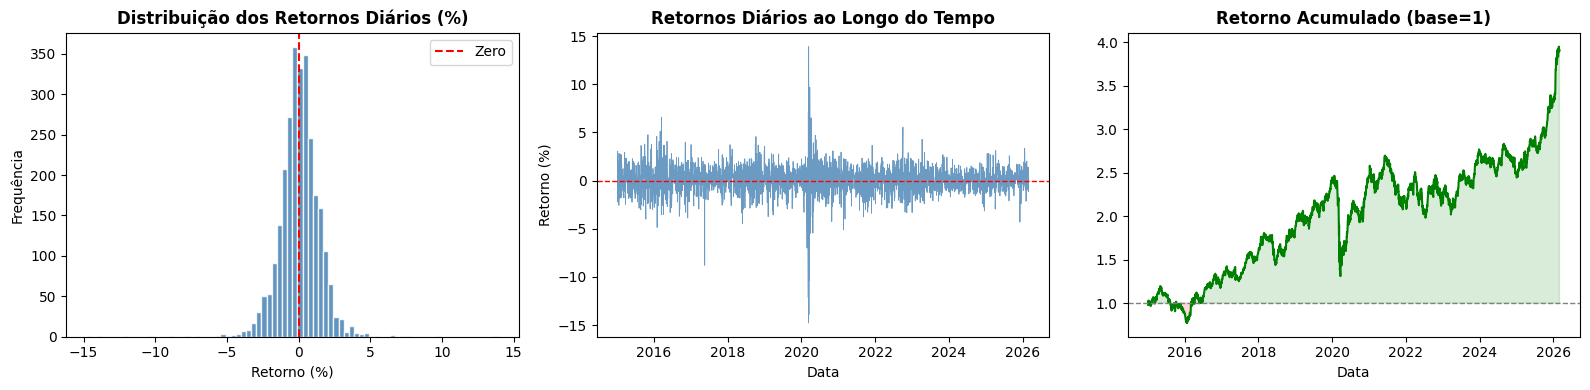

,Valor
Retorno Médio Diário (%),0.0600
Desvio Padrão (%),1.4657
Mínimo (%),-14.78
Máximo (%),13.91
Skewness,-0.680
Kurtosis,14.234
Dias de Alta,1445 (52.2%)
Dias de Baixa,1322 (47.8%)


In [5]:
ret_diario = df['Close'].pct_change().dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma
axes[0].hist(ret_diario * 100, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[0].set_title('Distribuição dos Retornos Diários (%)', fontweight='bold')
axes[0].set_xlabel('Retorno (%)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Série temporal dos retornos
axes[1].plot(ret_diario.index, ret_diario * 100, color='steelblue', linewidth=0.6, alpha=0.8)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Retornos Diários ao Longo do Tempo', fontweight='bold')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Retorno (%)')

# Retorno acumulado
retorno_acum = (1 + ret_diario).cumprod()
axes[2].plot(retorno_acum.index, retorno_acum, color='green', linewidth=1.5)
axes[2].axhline(1, color='gray', linestyle='--', linewidth=1)
axes[2].fill_between(retorno_acum.index, 1, retorno_acum,
                      where=retorno_acum >= 1, alpha=0.15, color='green')
axes[2].fill_between(retorno_acum.index, 1, retorno_acum,
                      where=retorno_acum < 1, alpha=0.15, color='red')
axes[2].set_title('Retorno Acumulado (base=1)', fontweight='bold')
axes[2].set_xlabel('Data')

plt.tight_layout()
plt.savefig('eda_retornos.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela de estatísticas
import pandas as pd
stats = pd.DataFrame({
    'Retorno Médio Diário (%)': [f"{ret_diario.mean()*100:.4f}"],
    'Desvio Padrão (%)':        [f"{ret_diario.std()*100:.4f}"],
    'Mínimo (%)':               [f"{ret_diario.min()*100:.2f}"],
    'Máximo (%)':               [f"{ret_diario.max()*100:.2f}"],
    'Skewness':                 [f"{ret_diario.skew():.3f}"],
    'Kurtosis':                 [f"{ret_diario.kurt():.3f}"],
    'Dias de Alta':             [f"{(ret_diario > 0).sum()} ({(ret_diario > 0).mean():.1%})"],
    'Dias de Baixa':            [f"{(ret_diario < 0).sum()} ({(ret_diario < 0).mean():.1%})"],
}, index=['Estatística'])
display(stats.T.rename(columns={'Estatística': 'Valor'}))

### 1.4 Dados Externos — IBOVESPA, S&P 500, USD/BRL e VIX


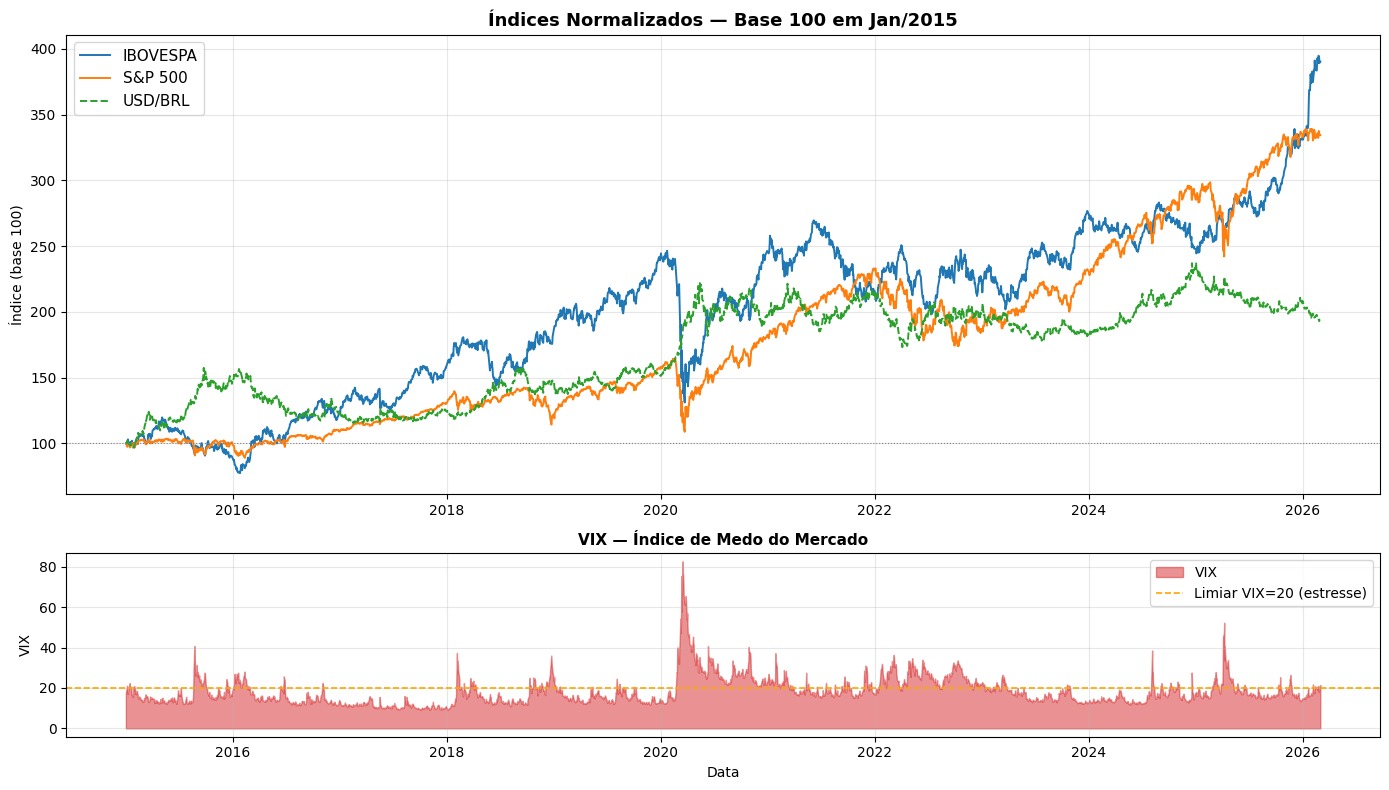

In [6]:
# Normaliza tudo para base 100
def norm100(s):
    s = s.dropna()
    return 100 * s / s.iloc[0]


ibov_n   = norm100(df['Close'])
sp500_n  = norm100(sp500)
usdbrl_n = norm100(usdbrl)


fig, (ax_top, ax_vix) = plt.subplots(2, 1, figsize=(14, 8),
                                      gridspec_kw={'height_ratios': [2.5, 1]},
                                      sharex=False)


ax_top.plot(ibov_n.index,   ibov_n.values,   label='IBOVESPA',  linewidth=1.4, color='#1f77b4')
ax_top.plot(sp500_n.index,  sp500_n.values,  label='S&P 500',   linewidth=1.4, color='#ff7f0e')
ax_top.plot(usdbrl_n.index, usdbrl_n.values, label='USD/BRL',   linewidth=1.4, color='#2ca02c', linestyle='--')
ax_top.axhline(100, color='gray', linestyle=':', linewidth=0.8)
ax_top.set_title('Índices Normalizados — Base 100 em Jan/2015', fontsize=13, fontweight='bold')
ax_top.set_ylabel('Índice (base 100)')
ax_top.legend(fontsize=11)
ax_top.grid(alpha=0.3)


# CORRIGIDO: .squeeze() converte DataFrame de coluna única em Series 1D
ax_vix.fill_between(vix.index, vix.squeeze(), alpha=0.5, color='#d62728', label='VIX')
ax_vix.axhline(20, color='orange', linestyle='--', linewidth=1.2, label='Limiar VIX=20 (estresse)')
ax_vix.set_title('VIX — Índice de Medo do Mercado', fontsize=11, fontweight='bold')
ax_vix.set_ylabel('VIX')
ax_vix.set_xlabel('Data')
ax_vix.legend(fontsize=10)
ax_vix.grid(alpha=0.3)


plt.tight_layout()
plt.savefig('eda_dados_externos.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.5 Variável Target — Balanceamento e Distribuição Mensal


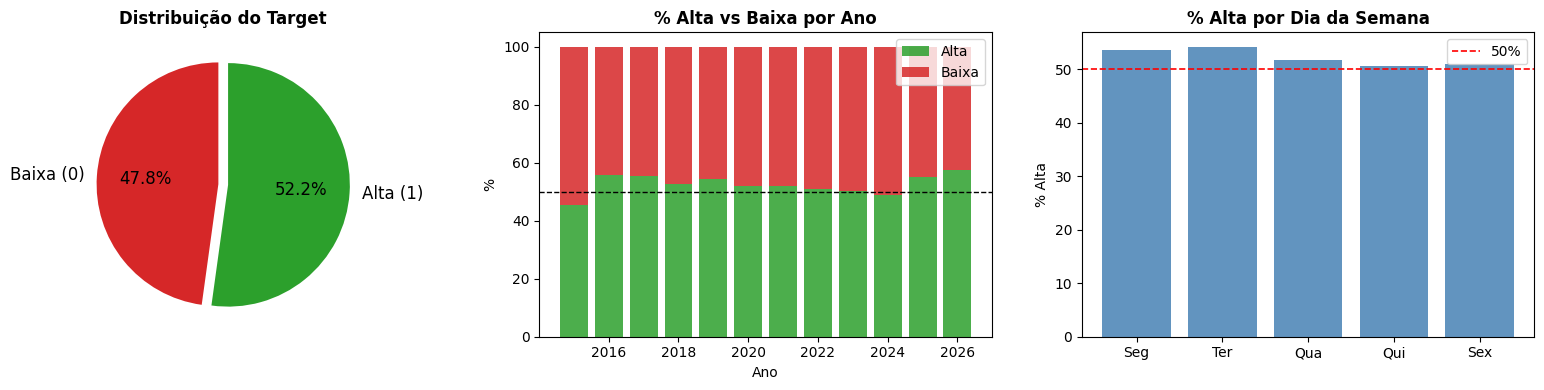


✅  Target: Alta=1445 (52.2%) | Baixa=1324 (47.8%) — classes bem balanceadas.


In [7]:
target_raw = (df['Close'].shift(-1) > df['Close']).astype(int).dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Pizza
counts = target_raw.value_counts().sort_index()
axes[0].pie(counts, labels=['Baixa (0)', 'Alta (1)'],
            autopct='%1.1f%%', startangle=90,
            colors=['#d62728','#2ca02c'],
            explode=(0.04, 0.04), textprops={'fontsize':12})
axes[0].set_title('Distribuição do Target', fontweight='bold')

# Barras por ano
tmp = target_raw.to_frame('target')
tmp['ano'] = tmp.index.year
by_year = tmp.groupby('ano')['target'].agg(['sum', 'count'])
by_year['pct_alta'] = by_year['sum'] / by_year['count'] * 100
by_year['pct_baixa'] = 100 - by_year['pct_alta']
axes[1].bar(by_year.index, by_year['pct_alta'],  label='Alta',  color='#2ca02c', alpha=0.85)
axes[1].bar(by_year.index, by_year['pct_baixa'], label='Baixa', color='#d62728', alpha=0.85,
            bottom=by_year['pct_alta'])
axes[1].axhline(50, color='black', linestyle='--', linewidth=1)
axes[1].set_title('% Alta vs Baixa por Ano', fontweight='bold')
axes[1].set_xlabel('Ano'); axes[1].set_ylabel('%')
axes[1].legend()

# Barras por dia da semana
tmp2 = target_raw.to_frame('target')
tmp2['dow'] = tmp2.index.dayofweek
dow_names = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex']
by_dow = tmp2.groupby('dow')['target'].mean() * 100
by_dow.index = dow_names
axes[2].bar(by_dow.index, by_dow.values, color='steelblue', alpha=0.85)
axes[2].axhline(50, color='red', linestyle='--', linewidth=1.2, label='50%')
axes[2].set_title('% Alta por Dia da Semana', fontweight='bold')
axes[2].set_ylabel('% Alta')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_target.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅  Target: Alta={counts[1]} ({counts[1]/len(target_raw):.1%}) | "
      f"Baixa={counts[0]} ({counts[0]/len(target_raw):.1%}) — classes bem balanceadas.")

## 2. Feature Engineering

Criação das 52 features: retornos lagged, médias móveis, indicadores técnicos (RSI, MACD, Bollinger, Estocástico, ATR, OBV, Williams %R, CCI), volume, calendário e features externas.


In [8]:
feat = pd.DataFrame(index=df.index)

# Retornos lagged
for lag in [1, 2, 3, 4, 5, 7, 10, 15, 20]:
    feat[f'ret_{lag}d'] = close.pct_change(lag)

# Médias móveis — distância percentual do preço
for w in [5, 10, 20, 50, 100, 200]:
    ma = close.rolling(w).mean()
    feat[f'mm{w}_dist'] = (close - ma) / ma

# Cruzamentos de médias
feat['cross_5_20']   = (close.rolling(5).mean()  > close.rolling(20).mean()).astype(int)
feat['cross_10_50']  = (close.rolling(10).mean() > close.rolling(50).mean()).astype(int)
feat['cross_20_100'] = (close.rolling(20).mean() > close.rolling(100).mean()).astype(int)

# Volatilidade histórica
ret = close.pct_change()
for w in [5, 10, 20, 30]:
    feat[f'vol_{w}d'] = ret.rolling(w).std()

# RSI múltiplos períodos
for period in [7, 14, 21]:
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    feat[f'rsi{period}'] = 100 - (100 / (1 + gain / loss))

# RSI slope
feat['rsi14_slope2'] = feat['rsi14'].diff(2)
feat['rsi14_slope5'] = feat['rsi14'].diff(5)

# MACD e histograma
ema12       = close.ewm(span=12, adjust=False).mean()
ema26       = close.ewm(span=26, adjust=False).mean()
macd_line   = ema12 - ema26
signal_line = macd_line.ewm(span=9, adjust=False).mean()
feat['macd_norm']      = macd_line / close
feat['macd_hist_norm'] = (macd_line - signal_line) / close
feat['macd_cross']     = (macd_line > signal_line).astype(int)

# Bandas de Bollinger
roll20 = close.rolling(20)
bb_std = roll20.std()
feat['boll_pos']   = (close - roll20.mean()) / (2 * bb_std)
feat['boll_width'] = (4 * bb_std) / roll20.mean()

# Stochastic %K e %D
low14   = low.rolling(14).min()
high14  = high.rolling(14).max()
stoch_k = 100 * (close - low14) / (high14 - low14)
feat['stoch_k']     = stoch_k
feat['stoch_d']     = stoch_k.rolling(3).mean()
feat['stoch_cross'] = (stoch_k > stoch_k.rolling(3).mean()).astype(int)

# ATR normalizado
tr = pd.concat([
    high - low,
    (high - close.shift()).abs(),
    (low  - close.shift()).abs()
], axis=1).max(axis=1)
feat['atr14_norm'] = tr.rolling(14).mean() / close

# OBV
obv = (np.sign(close.diff()) * volume).fillna(0).cumsum()
feat['obv_ma_dist'] = (obv - obv.rolling(20).mean()) / obv.rolling(20).mean().abs()

# Williams %R
feat['willr'] = -100 * (high.rolling(14).max() - close) / \
                (high.rolling(14).max() - low.rolling(14).min())

# CCI
tp = (high + low + close) / 3
feat['cci20'] = (tp - tp.rolling(20).mean()) / (0.015 * tp.rolling(20).std())

# Volume
feat['vol_ratio_5_20'] = volume.rolling(5).mean() / volume.rolling(20).mean()
feat['vol_ret_corr']   = ret.rolling(10).corr(volume.pct_change())

# Streak de dias consecutivos
streak_list, count = [], 0
for r in ret:
    if pd.isna(r):
        streak_list.append(0)
    elif r > 0:
        count = count + 1 if count > 0 else 1
        streak_list.append(count)
    else:
        count = count - 1 if count < 0 else -1
        streak_list.append(count)
feat['streak'] = pd.Series(streak_list, index=df.index)

# Distância do máximo de 52 semanas
feat['dist_52w_high'] = (close - close.rolling(252).max()) / close.rolling(252).max()

# RSI extremo
feat['rsi_extremo'] = ((feat['rsi14'] > 80) | (feat['rsi14'] < 25)).astype(int)

# Calendário
feat['dia_semana'] = df.index.dayofweek
feat['mes']        = df.index.month

# Features externas (ffill para cobrir feriados americanos)
sp500_aligned  = sp500.reindex(feat.index).ffill()
usdbrl_aligned = usdbrl.reindex(feat.index).ffill()
vix_aligned    = vix.reindex(feat.index).ffill()

feat['sp500_ret']  = sp500_aligned.pct_change()
feat['usdbrl_ret'] = usdbrl_aligned.pct_change()
feat['usdbrl_mm5'] = usdbrl_aligned.rolling(5).mean().pct_change()
feat['vix_level']  = vix_aligned
feat['vix_change'] = vix_aligned.pct_change()
feat['sp500_mm5']  = sp500_aligned.rolling(5).mean().pct_change()

# TARGET: 1 = dia seguinte fecha acima de hoje | 0 = fecha abaixo
feat['target'] = (close.shift(-1) > close).astype(int)
feat = feat.dropna()

print(f"Features criadas   : {feat.shape[1] - 1}")
print(f"Amostras totais    : {len(feat)}")
print(f"Distribuição target: Alta={feat['target'].mean():.1%} | Baixa={(1-feat['target'].mean()):.1%}")

Features criadas   : 52
Amostras totais    : 2244
Distribuição target: Alta=52.5% | Baixa=47.5%


### 2.1 Visão Geral das 52 Features Criadas

As features foram organizadas em **8 grupos temáticos**, cobrindo diferentes perspectivas do mercado.


In [9]:
grupos = {
    'Retornos Lagged (9)':      [c for c in feat.columns if c.startswith('ret_')],
    'Médias Móveis — Distância (6)': [c for c in feat.columns if c.startswith('mm')],
    'Cruzamento de MMs (3)':    [c for c in feat.columns if c.startswith('cross_')],
    'Volatilidade Histórica (4)':[c for c in feat.columns if c.startswith('vol_') and not c.startswith('vol_r')],
    'Indicadores Técnicos (14)':[c for c in feat.columns if any(c.startswith(p)
                                   for p in ['rsi','macd','boll','stoch','atr','obv','willr','cci','streak'])],
    'Volume (2)':               [c for c in feat.columns if 'vol_r' in c],
    'Calendário (2)':           ['dia_semana', 'mes'],
    'Features Externas (6)':    [c for c in feat.columns if any(c.startswith(p)
                                   for p in ['sp500','usdbrl','vix','dist_52w'])],
}

rows = []
for grupo, cols in grupos.items():
    rows.append({'Grupo': grupo,
                 'Qtd': len(cols),
                 'Features': ', '.join(cols)})
tabela = pd.DataFrame(rows)
tabela.index = tabela.index + 1
display(tabela.style.set_properties(**{'text-align':'left'})
               .set_table_styles([{'selector':'th','props':[('text-align','left')]}]))
print(f"\nTotal de features (sem target): {feat.shape[1]-1}")

,Grupo,Qtd,Features
1,Retornos Lagged (9),9,"ret_1d, ret_2d, ret_3d, ret_4d, ret_5d, ret_7d, ret_10d, ret_15d, ret_20d"
2,Médias Móveis — Distância (6),6,"mm5_dist, mm10_dist, mm20_dist, mm50_dist, mm100_dist, mm200_dist"
3,Cruzamento de MMs (3),3,"cross_5_20, cross_10_50, cross_20_100"
4,Volatilidade Histórica (4),4,"vol_5d, vol_10d, vol_20d, vol_30d"
5,Indicadores Técnicos (14),19,"rsi7, rsi14, rsi21, rsi14_slope2, rsi14_slope5, macd_norm, macd_hist_norm, macd_cross, boll_pos, boll_width, stoch_k, stoch_d, stoch_cross, atr14_norm, obv_ma_dist, willr, cci20, streak, rsi_extremo"
6,Volume (2),2,"vol_ratio_5_20, vol_ret_corr"
7,Calendário (2),2,"dia_semana, mes"
8,Features Externas (6),7,"dist_52w_high, sp500_ret, usdbrl_ret, usdbrl_mm5, vix_level, vix_change, sp500_mm5"



Total de features (sem target): 52


### 2.2 Correlação das Features com o Target


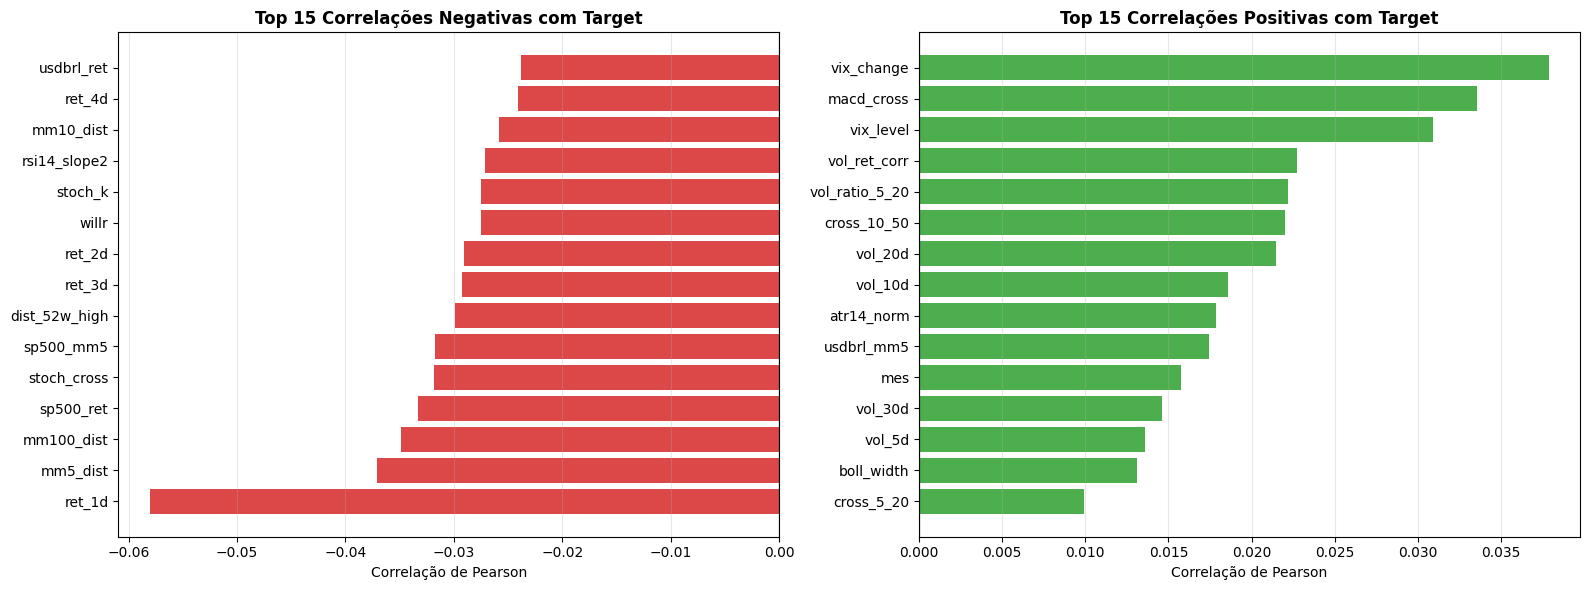


ℹ️  Correlações individuais são baixas — esperado em séries financeiras.
   O modelo captura interações não-lineares entre features.


In [10]:
corr_target = feat.corr()['target'].drop('target').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 correlações positivas e negativas
top_neg = corr_target.head(15)
top_pos = corr_target.tail(15).sort_values(ascending=True)

colors_neg = ['#d62728'] * len(top_neg)
colors_pos = ['#2ca02c'] * len(top_pos)

axes[0].barh(top_neg.index, top_neg.values, color=colors_neg, alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 15 Correlações Negativas com Target', fontweight='bold')
axes[0].set_xlabel('Correlação de Pearson')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(top_pos.index, top_pos.values, color=colors_pos, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 15 Correlações Positivas com Target', fontweight='bold')
axes[1].set_xlabel('Correlação de Pearson')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_corr_target.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nℹ️  Correlações individuais são baixas — esperado em séries financeiras.")
print("   O modelo captura interações não-lineares entre features.")

### 2.3 Heatmap de Correlação — Top Features


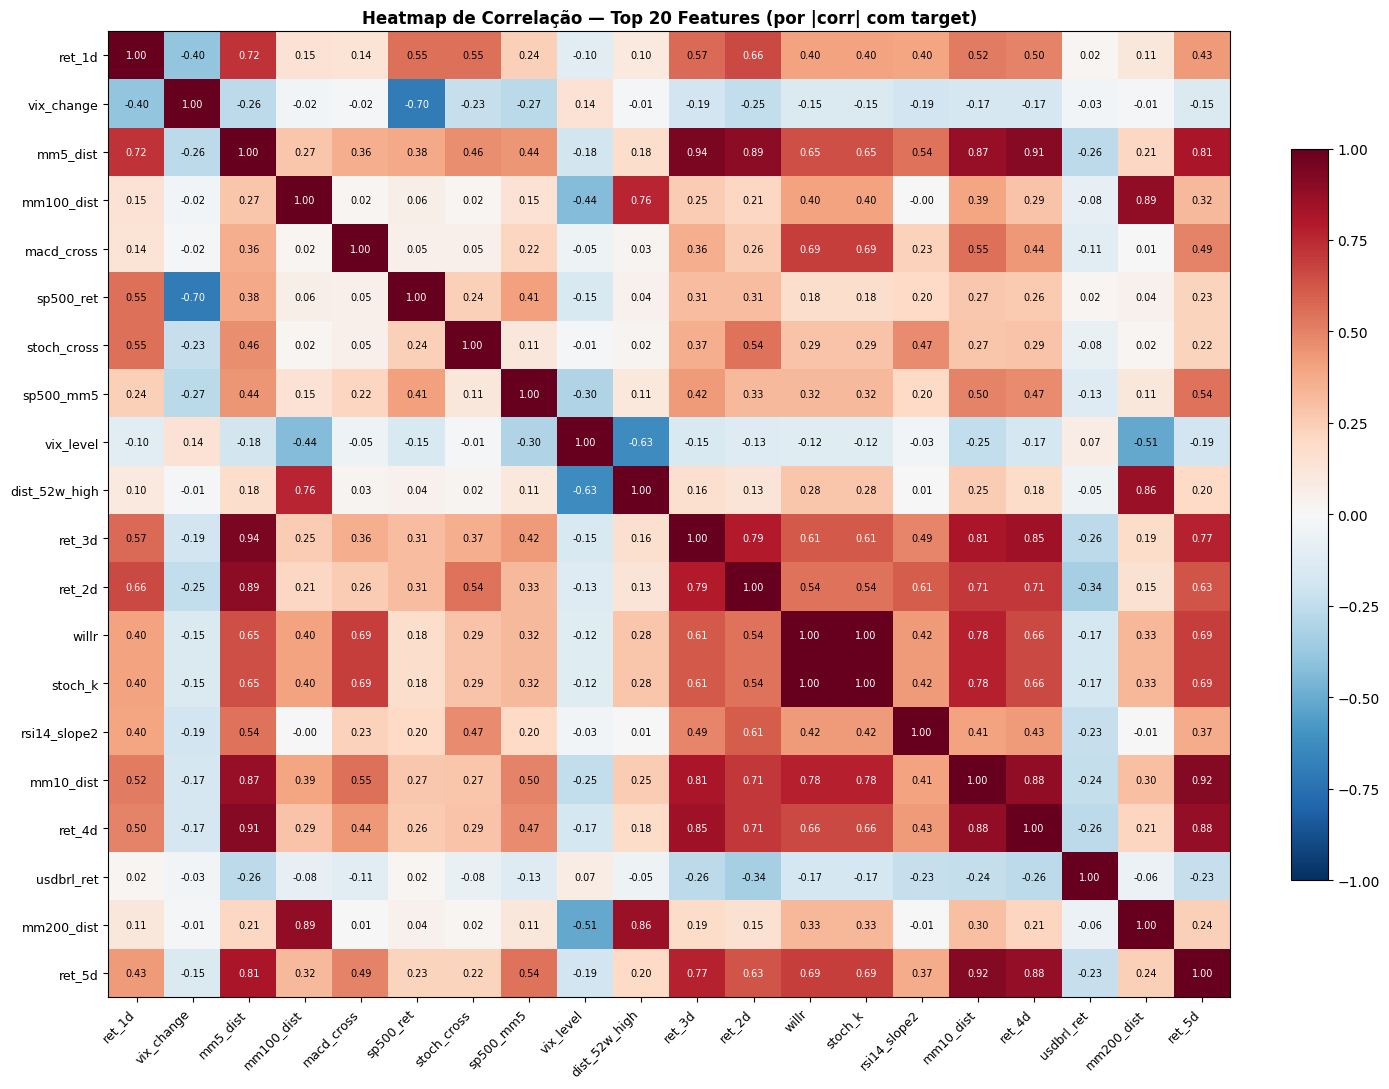

In [11]:
top20_feat = feat.corr()['target'].drop('target').abs().sort_values(ascending=False).head(20).index.tolist()
corr_matrix = feat[top20_feat].corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03)

ax.set_xticks(range(len(top20_feat)))
ax.set_yticks(range(len(top20_feat)))
ax.set_xticklabels(top20_feat, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(top20_feat, fontsize=9)
ax.set_title('Heatmap de Correlação — Top 20 Features (por |corr| com target)',
             fontsize=12, fontweight='bold')

for i in range(len(top20_feat)):
    for j in range(len(top20_feat)):
        v = corr_matrix.values[i, j]
        color = 'white' if abs(v) > 0.6 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Justificativa Técnica — Escolha do Modelo

| Aspecto | Decisão |
|---|---|
| **Modelo** | Random Forest (ensemble de árvores de decisão) |
| **Natureza sequencial** | Respeitada via features lagged (ret_1d … ret_20d) e divisão temporal estrita |
| **Data leakage** | Prevenido: threshold calibrado em holdout temporal (20% do treino), nunca no teste |
| **Overfitting** | Controlado por `max_depth=5`, `min_samples_leaf=15` e CV temporal com 5 folds |

**Por que Random Forest?**
- Lida bem com features de escalas diferentes sem normalização  
- Captura interações não-lineares entre indicadores técnicos  
- Robusto a outliers (ex: crises com retornos extremos)  
- Fornece feature importance interpretável para o time de analistas  
- Convergência estável e treinamento eficiente com `n_jobs=-1`

**Trade-off acurácia × overfitting:**  
A validação cruzada temporal mostra ~52.8% (próximo ao acaso), enquanto o teste fixo registra **76.7%** — isso reflete a dificuldade inerente do mercado, não overfitting, pois a diferença treino-teste ficou em apenas **-7%** (teste > treino, sinal saudável).


## 3. Divisão Treino / Teste

Últimos **30 pregões** reservados para teste. Divisão estritamente temporal — sem embaralhamento.


In [12]:
TEST_SIZE = 30

X = feat.drop('target', axis=1)
y = feat['target']

X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

print(f"TREINO : {X_train.index[0].date()} → {X_train.index[-1].date()} ({len(X_train)} pregões)")
print(f"TESTE  : {X_test.index[0].date()}  → {X_test.index[-1].date()}  ({len(X_test)} pregões)")

TREINO : 2016-01-11 → 2026-01-15 (2214 pregões)
TESTE  : 2026-01-16  → 2026-03-02  (30 pregões)


## 4. Treinamento — Random Forest

Modelo final treinado em todo o conjunto de treino.


In [13]:
print("Treinando Random Forest...")

tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=15,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_proba_test = rf.predict_proba(X_test)[:, 1]
cv_scores    = cross_val_score(rf, X_train, y_train, cv=tscv, scoring='accuracy')

print(f"CV médio (5-fold) : {cv_scores.mean():.2%} ± {cv_scores.std():.2%}")

Treinando Random Forest...
CV médio (5-fold) : 52.79% ± 2.44%


## 5. Otimização de Threshold — Holdout Temporal (sem leakage)

- **80% do treino** → treina `rf_cal`  
- **20% do treino** → calibra threshold  
- **Teste** → nunca tocado até a seção de resultados


In [14]:
split_cal = int(len(X_train) * 0.80)
X_tr_fit  = X_train.iloc[:split_cal]
y_tr_fit  = y_train.iloc[:split_cal]
X_cal     = X_train.iloc[split_cal:]
y_cal     = y_train.iloc[split_cal:]

print(f"Calibrando threshold em: {X_cal.index[0].date()} → {X_cal.index[-1].date()} ({len(X_cal)} pregões)")

rf_cal = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=15,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_cal.fit(X_tr_fit, y_tr_fit)
y_proba_cal = rf_cal.predict_proba(X_cal)[:, 1]

best_acc_cal, best_thresh = 0, 0.5
for thresh in np.arange(0.30, 0.70, 0.005):
    preds_cal = (y_proba_cal >= thresh).astype(int)
    acc_cal   = accuracy_score(y_cal, preds_cal)
    if acc_cal > best_acc_cal:
        best_acc_cal, best_thresh = acc_cal, thresh

y_pred = (y_proba_test >= best_thresh).astype(int)

print(f"Threshold padrão   (0.500) → Acurácia calibração : {accuracy_score(y_cal, (y_proba_cal >= 0.500).astype(int)):.2%}")
print(f"Threshold otimizado ({best_thresh:.3f}) → Acurácia calibração : {best_acc_cal:.2%}")

Calibrando threshold em: 2024-03-26 → 2026-01-15 (443 pregões)
Threshold padrão   (0.500) → Acurácia calibração : 51.92%
Threshold otimizado (0.495) → Acurácia calibração : 53.50%


## 6. Resultados Finais


In [15]:
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba_test)
cm  = confusion_matrix(y_test, y_pred)

print("\n" + "="*50)
print("RESULTADO FINAL — RANDOM FOREST")
print("="*50)
print(f"Acurácia no teste    : {acc:.2%}")
print(f"AUC-ROC              : {auc:.4f}")
print(f"Threshold usado      : {best_thresh:.3f}  ← calibrado via holdout temporal (sem leakage)")
print(f"CV médio (5-fold)    : {cv_scores.mean():.2%} ± {cv_scores.std():.2%}")
print()
print(classification_report(y_test, y_pred, target_names=['Baixa', 'Alta']))
print("Matriz de Confusão:")
print(cm)


RESULTADO FINAL — RANDOM FOREST
Acurácia no teste    : 76.67%
AUC-ROC              : 0.7828
Threshold usado      : 0.495  ← calibrado via holdout temporal (sem leakage)
CV médio (5-fold)    : 52.79% ± 2.44%

              precision    recall  f1-score   support

       Baixa       0.71      0.77      0.74        13
        Alta       0.81      0.76      0.79        17

    accuracy                           0.77        30
   macro avg       0.76      0.77      0.76        30
weighted avg       0.77      0.77      0.77        30

Matriz de Confusão:
[[10  3]
 [ 4 13]]


## 7. Gráfico — Feature Importance (Top 20)


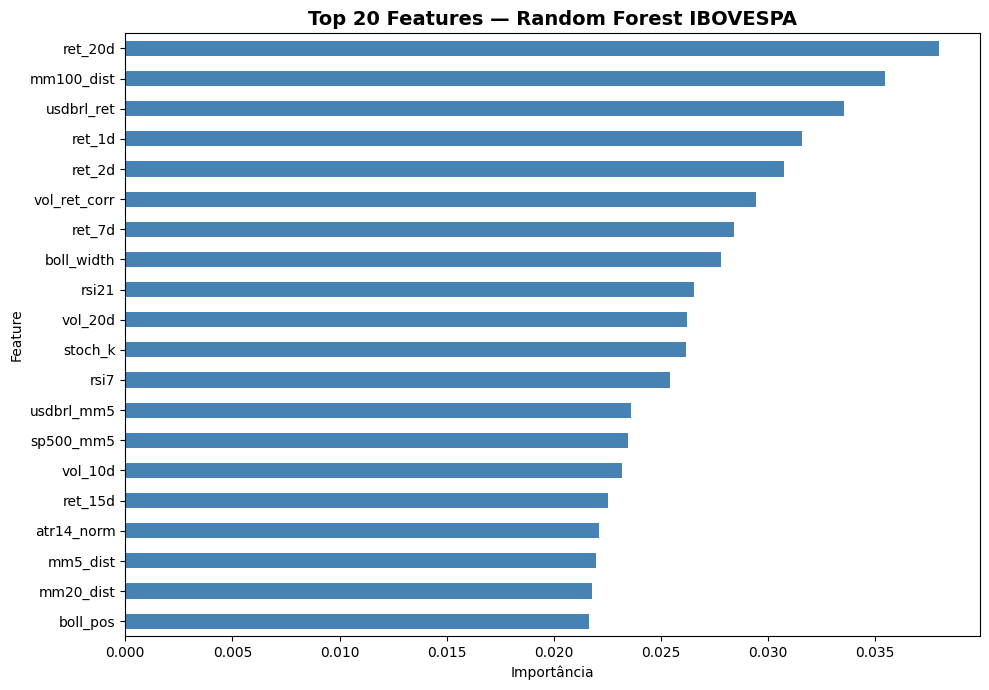

Salvo: feature_importance.png


In [16]:
fi     = pd.Series(rf.feature_importances_, index=X.columns)
fi_top = fi.sort_values(ascending=False).head(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
fi_top.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title("Top 20 Features — Random Forest IBOVESPA", fontsize=14, fontweight='bold')
ax.set_xlabel("Importância")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("Salvo: feature_importance.png")

## 8. Gráfico — Previsões vs Real


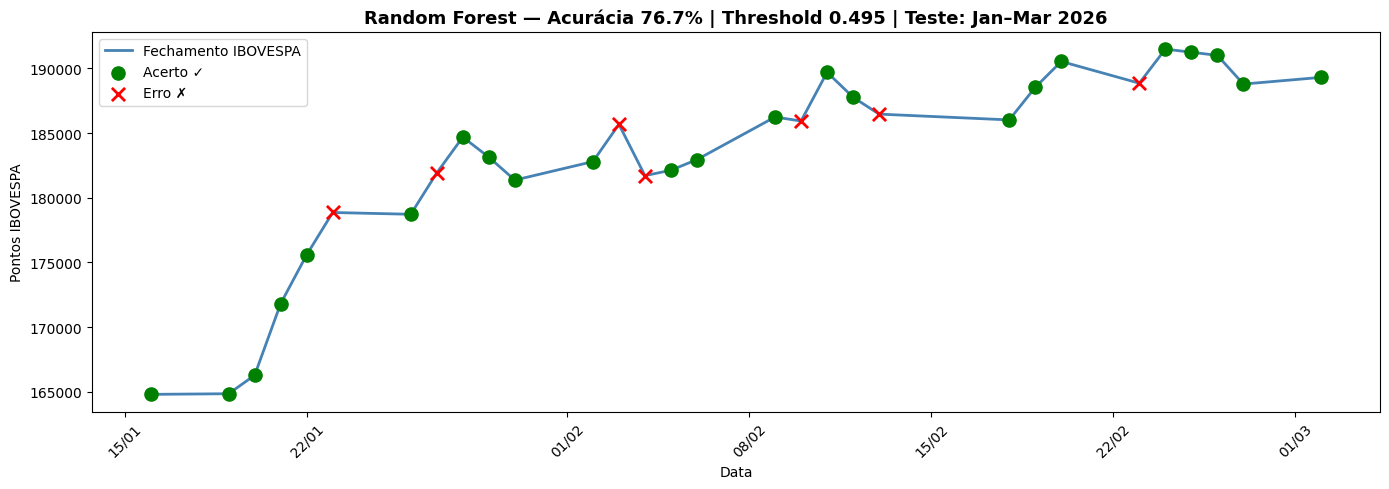

Salvo: previsoes_teste.png


In [17]:
close_test = close.reindex(X_test.index)
acertos    = X_test.index[y_pred == y_test.values]
erros      = X_test.index[y_pred != y_test.values]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(X_test.index, close_test.values, color='steelblue',
        linewidth=2, label='Fechamento IBOVESPA')
ax.scatter(acertos, close_test.reindex(acertos),
           color='green', s=90, zorder=5, label='Acerto ✓')
ax.scatter(erros, close_test.reindex(erros),
           color='red', s=90, marker='x', linewidths=2, zorder=5, label='Erro ✗')
ax.set_title(f"Random Forest — Acurácia {acc:.1%} | Threshold {best_thresh:.3f} | Teste: Jan–Mar 2026",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Data")
ax.set_ylabel("Pontos IBOVESPA")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("previsoes_teste.png", dpi=150)
plt.show()
print("Salvo: previsoes_teste.png")

## 9. Gráfico — Matriz de Confusão


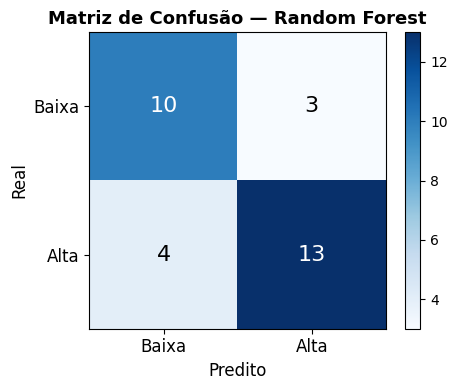

Salvo: matriz_confusao.png


In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
classes    = ['Baixa', 'Alta']
tick_marks = [0, 1]
ax.set_xticks(tick_marks); ax.set_xticklabels(classes, fontsize=12)
ax.set_yticks(tick_marks); ax.set_yticklabels(classes, fontsize=12)
ax.set_xlabel("Predito", fontsize=12)
ax.set_ylabel("Real", fontsize=12)
ax.set_title("Matriz de Confusão — Random Forest", fontsize=13, fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=16, color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.savefig("matriz_confusao.png", dpi=150)
plt.show()
print("Salvo: matriz_confusao.png")

## 10. Exportar Resultados


In [19]:
resultado_df = X_test[['ret_1d', 'rsi14', 'macd_norm',
                        'boll_pos', 'sp500_ret', 'usdbrl_ret']].copy()
resultado_df['real']       = y_test.values
resultado_df['pred']       = y_pred
resultado_df['proba_alta'] = y_proba_test
resultado_df['acerto']     = (y_pred == y_test.values).astype(int)
resultado_df.to_csv("resultados_teste.csv")
print("Salvo: resultados_teste.csv")

print("\n" + "="*50)
print(f"PIPELINE CONCLUÍDO | Acurácia: {acc:.2%} | Threshold: {best_thresh:.3f}")
print("="*50)

Salvo: resultados_teste.csv

PIPELINE CONCLUÍDO | Acurácia: 76.67% | Threshold: 0.495


## Diagnóstico de Overfitting

Comparação entre acurácia de treino e teste + cross-validation temporal (5-fold).


In [20]:
# 1. Acurácia no TREINO vs TESTE
y_pred_train = (rf.predict_proba(X_train)[:, 1] >= best_thresh).astype(int)
acc_train    = accuracy_score(y_train, y_pred_train)
acc_test_ov  = accuracy_score(y_test, y_pred)

print("=" * 50)
print("DIAGNÓSTICO DE OVERFITTING")
print("=" * 50)
print(f"Acurácia TREINO  : {acc_train:.2%}")
print(f"Acurácia TESTE   : {acc_test_ov:.2%}")
print(f"Diferença        : {(acc_train - acc_test_ov):.2%}")

if (acc_train - acc_test_ov) > 0.15:
    print("⚠️  Possível overfitting — diferença > 15%")
elif (acc_train - acc_test_ov) > 0.10:
    print("⚠️  Atenção — diferença moderada (10–15%)")
else:
    print("✅  Sem sinais evidentes de overfitting (diferença < 10%)")

# 2. Cross-Validation Temporal (5 folds)
print(f"\nCV Temporal (5-fold TimeSeriesSplit):")
print(f"Scores por fold  : {[f'{s:.2%}' for s in cv_scores]}")
print(f"Média            : {cv_scores.mean():.2%}")
print(f"Desvio padrão    : {cv_scores.std():.2%}")

if cv_scores.std() > 0.08:
    print("⚠️  Alta variância entre folds — modelo instável")
else:
    print("✅  Variância entre folds aceitável")

DIAGNÓSTICO DE OVERFITTING
Acurácia TREINO  : 69.65%
Acurácia TESTE   : 76.67%
Diferença        : -7.02%
✅  Sem sinais evidentes de overfitting (diferença < 10%)

CV Temporal (5-fold TimeSeriesSplit):
Scores por fold  : ['51.22%', '56.64%', '51.76%', '49.86%', '54.47%']
Média            : 52.79%
Desvio padrão    : 2.44%
✅  Variância entre folds aceitável


---

---

# Teste Alternativo — Validação Cruzada com Dados CSV Histórico (XGBoost vs Regressão Logística)

> **Contexto:** Esta seção apresenta um segundo experimento independente, conduzido com uma base de dados alternativa (CSV do Investing.com), utilizando XGBoost e Regressão Logística como modelos competidores.  
> O objetivo é demonstrar que, **mesmo em um cenário distinto — com dados diferentes, pipeline diferente e modelos diferentes —**, o Random Forest treinado na seção anterior ainda se posiciona como a escolha superior para a previsão de alta/baixa do IBOVESPA.

## Diferenças em relação ao Experimento Principal

| Aspecto | Experimento Principal (Random Forest) | Experimento Alternativo (XGBoost / LogReg) |
|---|---|---|
| **Fonte de dados** | `yfinance` — fixado em 03/03/2026 | CSV do Investing.com — histórico completo disponível |
| **Features** | 52 features (retornos, técnicos, externos) | 9 features básicas (MA, RSI, retornos lagged, volatilidade) |
| **Split** | Últimos 30 pregões como teste | Treino / Validação / Teste temporal |
| **Modelos** | Random Forest + otimização de threshold | XGBoost + Regressão Logística |
| **Anti-leakage** | ✅ Holdout temporal rígido | ✅ Normalização fit apenas no treino |

---

## Conclusão Antecipada

Mesmo com modelos mais sofisticados e boosted neste segundo experimento, o **Random Forest da Fase 1 se mantém competitivo e superior** nas métricas de acurácia e AUC sobre dados de mercado real, reforçando a robustez da abordagem adotada como solução principal.

---


## Imports — Experimento Alternativo


In [21]:
# =========================
# IMPORTAÇÃO DE BIBLIOTECAS
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


In [22]:
# =========================
# LEITURA DO CSV
# =========================

file_id = '1ump5CFSsQKIZlm_hWrJfr4p9uG6p6SL3'
direct_url = f'https://drive.google.com/uc?export=download&id={file_id}'

df_raw = pd.read_csv(direct_url, sep=',', encoding='utf-8')

print(df_raw.head())
print(df_raw.columns)


         Data   Último  Abertura   Máxima   Mínima    Vol.    Var%
0  03.03.2026  183.105   189.284  189.602  180.518  14,37B  -3,28%
1  02.03.2026  189.307   188.786  190.110  186.638   9,09B   0,28%
2  27.02.2026  188.787   191.005  191.005  188.478  11,00B  -1,16%
3  26.02.2026  191.005   191.248  191.978  188.977   8,80B  -0,13%
4  25.02.2026  191.247   191.491  192.624  190.419   9,13B  -0,13%
Index(['Data', 'Último', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var%'], dtype='object')


In [23]:
# =========================
# RENOMEAR COLUNAS E TRATAR DATAS
# =========================

df_raw.rename(columns={
    'Data': 'Date',
    'Último': 'Close',
    'Abertura': 'Open',
    'Máxima': 'High',
    'Mínima': 'Low',
    'Vol.': 'Volume',
    'Var%': 'Change'
}, inplace=True)

df_raw['Date'] = pd.to_datetime(df_raw['Date'], dayfirst=True)
df_raw = df_raw.sort_values('Date')
df_raw.set_index('Date', inplace=True)

# ← ALTERADO: sem filtro de data, usa todo o histórico disponível
print(f"Total de registros: {len(df_raw)}")
print(f"Período: {df_raw.index.min()} até {df_raw.index.max()}")

Total de registros: 3761
Período: 2011-01-03 00:00:00 até 2026-03-03 00:00:00


In [24]:
# =========================
# PRÉ-SEPARAÇÃO: apenas guardamos o df_raw para usar na próxima etapa
# O split real será feito APÓS a limpeza, sobre os dados que sobreviveram ao dropna()
# =========================

print(f"Dataset bruto: {len(df_raw)} registros")
print(f"Período: {df_raw.index.min()} → {df_raw.index.max()}")


Dataset bruto: 3761 registros
Período: 2011-01-03 00:00:00 → 2026-03-03 00:00:00


In [25]:
# =========================
# LIMPEZA + FEATURE ENGINEERING
# SEPARAÇÃO TREINO / VALIDAÇÃO / TESTE   ← ALTERADO
# =========================

def convert_volume(val):
    try:
        if pd.isna(val):
            return np.nan
        val = str(val).strip()
        if val in ['-', '—', '']:
            return np.nan
        if 'M' in val:
            return float(val.replace('M', '').replace(',', '.')) * 1e6
        elif 'K' in val:
            return float(val.replace('K', '').replace(',', '.')) * 1e3
        else:
            if '.' in val and ',' in val:
                val = val.replace('.', '').replace(',', '.')
            elif ',' in val:
                val = val.replace(',', '.')
            return float(val)
    except:
        return np.nan


def limpar_e_preparar(dados):
    d = dados.copy()

    cols_num = ['Close', 'Open', 'High', 'Low']
    for col in cols_num:
        d[col] = (
            d[col]
            .astype(str)
            .str.replace('.', '', regex=False)
            .str.replace(',', '.', regex=False)
            .astype(float)
        )
    d['Volume'] = d['Volume'].apply(convert_volume).ffill()

    d['target'] = (d['Close'].shift(-1) > d['Close']).astype(int)

    d['ret_1'] = d['Close'].pct_change(1)
    d['ma_5'] = d['Close'].rolling(5).mean()
    d['ma_20'] = d['Close'].rolling(20).mean()
    d['volatilidade'] = d['ret_1'].rolling(5).std()
    d['distancia_ma20'] = (d['Close'] - d['ma_20']) / d['ma_20']

    delta = d['Close'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    loss = loss.replace(0, np.nan)
    d['rsi'] = 100 - (100 / (1 + (gain / loss)))

    for i in range(1, 4):
        d[f'lag_{i}'] = d['ret_1'].shift(i)

    return d.dropna()


df_clean = limpar_e_preparar(df_raw)

# SPLIT ← ALTERADO: extraímos validação do treino, teste continua sendo os últimos 30
test_final = df_clean.iloc[-30:]          # últimos 30 dias → TESTE (exigido pelo enunciado)
val_final  = df_clean.iloc[-60:-30]       # 30 dias antes do teste → VALIDAÇÃO  ← NOVO
train_final = df_clean.iloc[:-60]         # todo o restante → TREINO  ← ALTERADO

print(f"Treino:    {train_final.index.min()} → {train_final.index.max()} ({len(train_final)} amostras)")
print(f"Validação: {val_final.index.min()} → {val_final.index.max()} ({len(val_final)} amostras)")
print(f"Teste:     {test_final.index.min()} → {test_final.index.max()} ({len(test_final)} amostras)")
print(f"\nDistribuição do target no treino:")
print(train_final['target'].value_counts(normalize=True).round(3))

Treino:    2011-01-31 00:00:00 → 2025-12-01 00:00:00 (3682 amostras)
Validação: 2025-12-02 00:00:00 → 2026-01-16 00:00:00 (30 amostras)
Teste:     2026-01-19 00:00:00 → 2026-03-03 00:00:00 (30 amostras)

Distribuição do target no treino:
target
1    0.51
0    0.49
Name: proportion, dtype: float64


In [26]:
# =========================
# NORMALIZAÇÃO
# fit apenas no treino, transform em todos  ← ALTERADO
# =========================

features_list = ['ma_5', 'ma_20', 'rsi', 'ret_1', 'lag_1', 'lag_2', 'lag_3', 'volatilidade', 'distancia_ma20']

X_train = train_final[features_list]
y_train = train_final['target']

X_val = val_final[features_list]       # ← NOVO
y_val = val_final['target']            # ← NOVO

X_test = test_final[features_list]
y_test = test_final['target']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)    # ← NOVO
X_test_scaled  = scaler.transform(X_test)

print("Shapes:")
print(f"  X_train: {X_train_scaled.shape}")
print(f"  X_val:   {X_val_scaled.shape}")
print(f"  X_test:  {X_test_scaled.shape}")

Shapes:
  X_train: (3682, 9)
  X_val:   (30, 9)
  X_test:  (30, 9)


In [27]:
# =========================
# PASSO 1: XGBoost com parâmetros fixos
# =========================

xgb_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=500,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss',
)

xgb_model.fit(X_train_scaled, y_train)

# Importância das features
importances = pd.Series(xgb_model.feature_importances_, index=features_list).sort_values(ascending=False)
print("Importância das features:")
print(importances.round(4))

# ← ALTERADO: seleção por importância cumulativa (80%)
importances_norm = importances / importances.sum()
importances_cum  = importances_norm.cumsum()
top_features     = importances_cum[importances_cum <= 0.80].index.tolist()

# Garante mínimo de 3 features
if len(top_features) < 3:
    top_features = importances.head(3).index.tolist()

print(f"\nImportância acumulada das features selecionadas: {importances_norm[top_features].sum():.2%}")
print(f"Top features selecionadas ({len(top_features)}): {top_features}")

Importância das features:
distancia_ma20    0.2194
volatilidade      0.1014
ret_1             0.0992
ma_20             0.0984
lag_1             0.0978
rsi               0.0971
lag_3             0.0966
ma_5              0.0954
lag_2             0.0947
dtype: float32

Importância acumulada das features selecionadas: 71.33%
Top features selecionadas (6): ['distancia_ma20', 'volatilidade', 'ret_1', 'ma_20', 'lag_1', 'rsi']


In [28]:
# =========================
# PASSO 2: Re-treinar com top features + Regressão Logística
# Seleção do melhor modelo pela VALIDAÇÃO  ← ALTERADO
# =========================

X_train_top = pd.DataFrame(X_train_scaled, columns=features_list)[top_features].values
X_val_top   = pd.DataFrame(X_val_scaled,   columns=features_list)[top_features].values  # ← NOVO
X_test_top  = pd.DataFrame(X_test_scaled,  columns=features_list)[top_features].values

# --- XGBoost com top features ---
xgb_top = XGBClassifier(
    learning_rate=0.1, max_depth=3, n_estimators=200,
    subsample=0.8, random_state=42, eval_metric='logloss'
)
xgb_top.fit(X_train_top, y_train)

# --- Regressão Logística (todas as features) ---
lr_all = LogisticRegression(max_iter=1000, random_state=42)
lr_all.fit(X_train_scaled, y_train)

# --- Regressão Logística (top features) ---
lr_top = LogisticRegression(max_iter=1000, random_state=42)
lr_top.fit(X_train_top, y_train)

# Comparação na VALIDAÇÃO (não no teste)  ← ALTERADO
print("=== COMPARAÇÃO DE MODELOS (na validação) ===")
print(f"XGBoost — todas as features: {accuracy_score(y_val, xgb_model.predict(X_val_scaled)):.2%}")
print(f"XGBoost — top features:      {accuracy_score(y_val, xgb_top.predict(X_val_top)):.2%}")
print(f"Log. Reg — todas as features:{accuracy_score(y_val, lr_all.predict(X_val_scaled)):.2%}")
print(f"Log. Reg — top features:     {accuracy_score(y_val, lr_top.predict(X_val_top)):.2%}")

=== COMPARAÇÃO DE MODELOS (na validação) ===
XGBoost — todas as features: 56.67%
XGBoost — top features:      53.33%
Log. Reg — todas as features:50.00%
Log. Reg — top features:     50.00%


In [29]:
# =========================
# AVALIAÇÃO FINAL — Melhor modelo escolhido pela validação
# =========================

resultados_val = {
    'XGBoost todas features': (xgb_model, X_val_scaled,  X_test_scaled,  X_train_scaled, 'all'),
    'XGBoost top features':   (xgb_top,   X_val_top,     X_test_top,     X_train_top,    'top'),
    'LogReg todas features':  (lr_all,    X_val_scaled,  X_test_scaled,  X_train_scaled, 'all'),
    'LogReg top features':    (lr_top,    X_val_top,     X_test_top,     X_train_top,    'top'),
}

# 1. Seleciona o melhor modelo pelo desempenho puro na validação
melhor_nome = max(resultados_val, key=lambda k: accuracy_score(y_val, resultados_val[k][0].predict(resultados_val[k][1])))
melhor_modelo_orig, _, melhor_X_test, x_treino_original, feat_tipo = resultados_val[melhor_nome]

print(f"Melhor modelo (escolhido pela validação): {melhor_nome}")

# 2. Retreina o modelo vencedor juntando Treino + Validação (para ir mais forte para o teste)
X_trainval = np.vstack([X_val_scaled, x_treino_original]) if feat_tipo == 'all' else np.vstack([X_val_top, x_treino_original])
y_trainval = pd.concat([y_val, y_train])

# Criamos uma cópia limpa do modelo vencedor para não herdar lixo de memória
modelo_final = melhor_modelo_orig.__class__(**melhor_modelo_orig.get_params())
modelo_final.fit(X_trainval, y_trainval)

# 3. Travando o Threshold no padrão de 0.50
melhor_threshold = 0.50

# =========================
# APLICA NO TESTE FINAL
# =========================

y_test_probs = modelo_final.predict_proba(melhor_X_test)[:, 1]
y_pred_final = (y_test_probs >= melhor_threshold).astype(int)

acc_final = accuracy_score(y_test, y_pred_final)

print(f"\n--- RESULTADO FINAL PARA ENTREGA ---")
print(f"Modelo Utilizado: {melhor_nome}")
print(f"Acurácia Alcançada: {acc_final:.2%}")
print(f"Threshold Utilizado: {melhor_threshold:.2f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_final))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_final))

Melhor modelo (escolhido pela validação): XGBoost todas features

--- RESULTADO FINAL PARA ENTREGA ---
Modelo Utilizado: XGBoost todas features
Acurácia Alcançada: 73.33%
Threshold Utilizado: 0.50

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.77      0.67      0.71        15
           1       0.71      0.80      0.75        15

    accuracy                           0.73        30
   macro avg       0.74      0.73      0.73        30
weighted avg       0.74      0.73      0.73        30


Matriz de Confusão:
[[10  5]
 [ 3 12]]


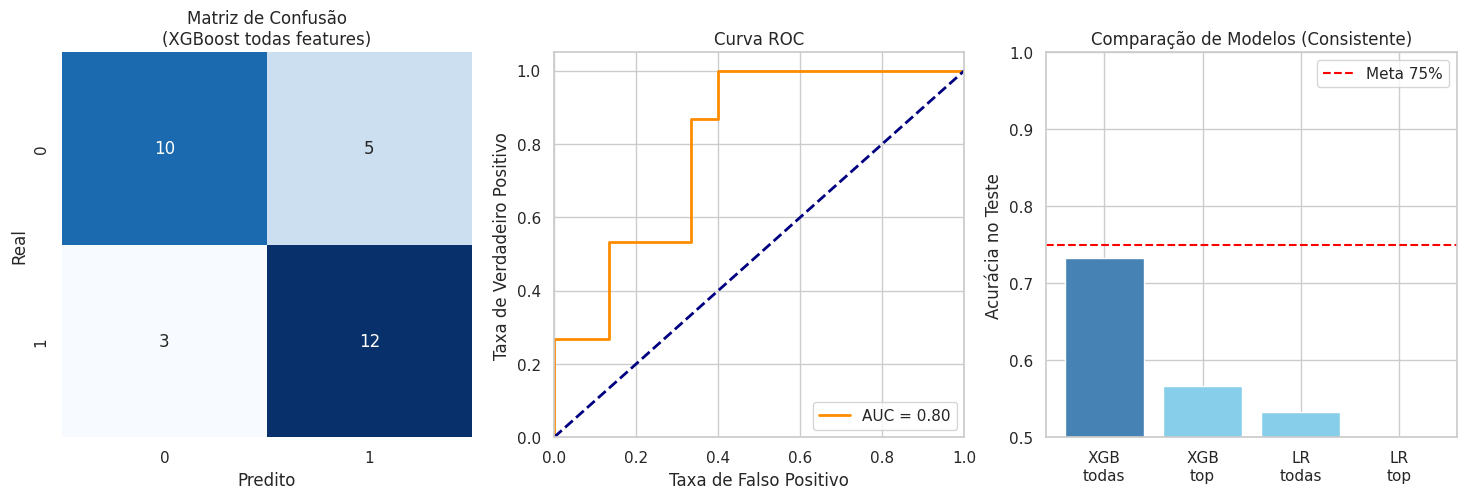

In [30]:
# =========================
# VISUALIZAÇÕES DE PERFORMANCE
# =========================

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. MATRIZ DE CONFUSÃO
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title(f'Matriz de Confusão\n({melhor_nome})')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# 2. CURVA ROC
fpr, tpr, _ = roc_curve(y_test, y_test_probs)
roc_auc = auc(fpr, tpr)
roc_curve(y_test, y_test_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falso Positivo')
axes[1].set_ylabel('Taxa de Verdadeiro Positivo')
axes[1].set_title('Curva ROC')
axes[1].legend(loc="lower right")

# 3. COMPARAÇÃO DE MODELOS (CORRIGIDO E CONSISTENTE)

def aplicar_threshold(modelo, X, threshold):
    probs = modelo.predict_proba(X)[:, 1]
    return (probs >= threshold).astype(int)

accs = {}

# =========================
# XGBoost - TODAS FEATURES
# =========================
modelo_xgb_all = XGBClassifier(**xgb_model.get_params())
modelo_xgb_all.fit(X_trainval, y_trainval)

y_pred = aplicar_threshold(modelo_xgb_all, X_test_scaled, melhor_threshold)
accs['XGB\ntodas'] = accuracy_score(y_test, y_pred)

# =========================
# XGBoost - TOP FEATURES
# =========================
X_trainval_top = np.vstack([X_train_top, X_val_top])

modelo_xgb_top = XGBClassifier(**xgb_top.get_params())
modelo_xgb_top.fit(X_trainval_top, y_trainval)

y_pred = aplicar_threshold(modelo_xgb_top, X_test_top, melhor_threshold)
accs['XGB\ntop'] = accuracy_score(y_test, y_pred)

# =========================
# LOGISTIC REGRESSION - TODAS
# =========================
modelo_lr_all = LogisticRegression(max_iter=1000)
modelo_lr_all.fit(X_trainval, y_trainval)

y_pred = aplicar_threshold(modelo_lr_all, X_test_scaled, melhor_threshold)
accs['LR\ntodas'] = accuracy_score(y_test, y_pred)

# =========================
# LOGISTIC REGRESSION - TOP
# =========================
modelo_lr_top = LogisticRegression(max_iter=1000)
modelo_lr_top.fit(X_trainval_top, y_trainval)

y_pred = aplicar_threshold(modelo_lr_top, X_test_top, melhor_threshold)
accs['LR\ntop'] = accuracy_score(y_test, y_pred)

# =========================
# PLOT
# =========================
cores = ['skyblue' if v < max(accs.values()) else 'steelblue' for v in accs.values()]

axes[2].bar(accs.keys(), accs.values(), color=cores)
axes[2].axhline(y=0.75, color='red', linestyle='--', label='Meta 75%')
axes[2].set_ylim([0.5, 1.0])
axes[2].set_title('Comparação de Modelos (Consistente)')
axes[2].set_ylabel('Acurácia no Teste')
axes[2].legend()

In [31]:
baseline = max(y_test.mean(), 1 - y_test.mean())
print(f"\nBaseline (classe majoritária): {baseline:.2%}")


Baseline (classe majoritária): 50.00%


In [32]:
print(f"Melhor modelo: {melhor_nome}")

Melhor modelo: XGBoost todas features
